# Análise Exploratória do Conjunto de Treinamento

Este notebook realiza a inspeção inicial do conjunto de treinamento utilizado
na tarefa de classificação da clareza de respostas do e-SIC.

Objetivos:

- verificar a estrutura e a qualidade dos dados;
- analisar a distribuição das classes;
- identificar valores ausentes e duplicatas;
- analisar o comprimento dos textos;
- investigar possíveis problemas de vazamento entre treino e validação;
- obter informações necessárias para definir a configuração dos modelos de PLN.

In [40]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [41]:
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "train.xlsx"

DATA_PATH

df = pd.read_excel(DATA_PATH, sheet_name="train")

df.head()

df["resp_text"] = df["resp_text"].astype(str)

## 1. Estrutura do conjunto de dados

In [42]:
print(f"Número de instâncias: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

df.columns.tolist()

df.info()

df.sample(5, random_state=42)



Número de instâncias: 20092
Número de colunas: 2
<class 'pandas.DataFrame'>
RangeIndex: 20092 entries, 0 to 20091
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   resp_text  20092 non-null  str  
 1   clarity    20092 non-null  str  
dtypes: str(2)
memory usage: 20.2 MB


,resp_text,clarity
8902,"Prezado (a) Cidadão (ã), 1.Conforme solic...",c234
2812,"Prezado senhor, a Susep não dispõe do documen...",c1
1606,"Prezado Senhor, Encaminhamos em anexo respos...",c1
19362,"Senhor Luciano, segue, em anexo, documento em...",c5
15968,"Prezada Daniele, Encaminhamos para conhecim...",c234


## 2. Valores ausentes

In [43]:
df.isna().sum()

(df["resp_text"].str.strip() == "").sum()

df.loc[df["resp_text"].str.strip().str.len() <= 20, ["resp_text", "clarity"]]

,resp_text,clarity
946,Prezado Senhor.,c1
1020,"Prezado (a) Sr. (a),",c1
1191,"Prezada Sr.,",c5
1490,Segue em anexo.,c1
1797,"Prezado Sr. Rafael,",c234
...,...,...
19678,Segue em anexo.,c234
19800,"Prezado Cidadão,",c1
19868,Em anexo.,c5
19888,"Prezado (a) Sr. (a),",c5


## 3. Distribuição das classes

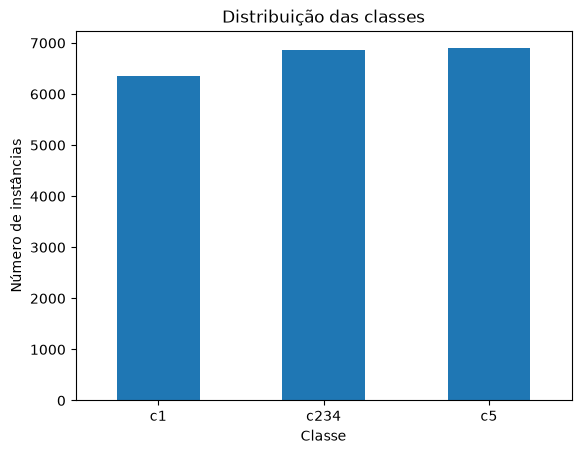

In [44]:
class_counts = df["clarity"].value_counts().sort_index()
class_proportions = (
    df["clarity"]
    .value_counts(normalize=True)
    .sort_index()
)

class_distribution = pd.DataFrame({
    "quantidade": class_counts,
    "proporcao": class_proportions,
})

class_distribution

ax = class_counts.plot(kind="bar")

ax.set_title("Distribuição das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Número de instâncias")

plt.xticks(rotation=0)
plt.show()

## 4. Análise de textos duplicados

Textos duplicados merecem atenção especial porque, caso a mesma resposta seja
distribuída entre treinamento e validação, o desempenho estimado pode ser
artificialmente elevado.

In [45]:
n_duplicate_rows = df.duplicated().sum()
n_duplicate_texts = df.duplicated(subset=["resp_text"]).sum()

print("Linhas completamente duplicadas:", n_duplicate_rows)
print("Ocorrências adicionais de textos repetidos:", n_duplicate_texts)
print("Textos únicos:", df["resp_text"].nunique())

duplicate_analysis = (
    df.groupby("resp_text")["clarity"]
      .agg(
          quantidade="size",
          numero_rotulos="nunique",
          rotulos=lambda x: sorted(set(x)),
      )
)

duplicate_analysis = duplicate_analysis[
    duplicate_analysis["quantidade"] > 1
]

duplicate_analysis.sort_values(
    "quantidade",
    ascending=False
).head(20)

conflicting_duplicates = duplicate_analysis[
    duplicate_analysis["numero_rotulos"] > 1
]

print("Textos repetidos:", len(duplicate_analysis))
print(
    "Textos repetidos que aparecem com rótulos diferentes:",
    len(conflicting_duplicates)
)

Linhas completamente duplicadas: 1279
Ocorrências adicionais de textos repetidos: 1660
Textos únicos: 18432
Textos repetidos: 463
Textos repetidos que aparecem com rótulos diferentes: 291


## 5. Comprimento das respostas

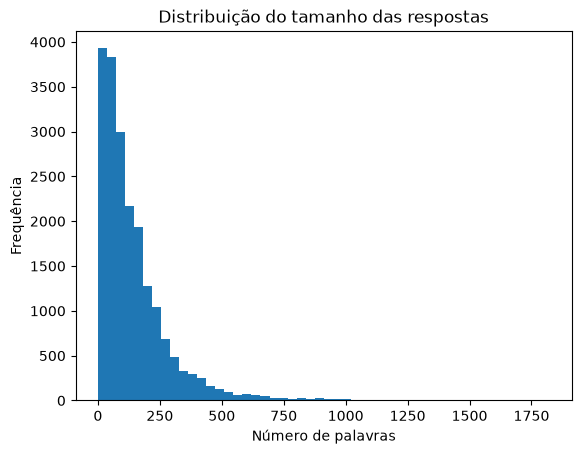

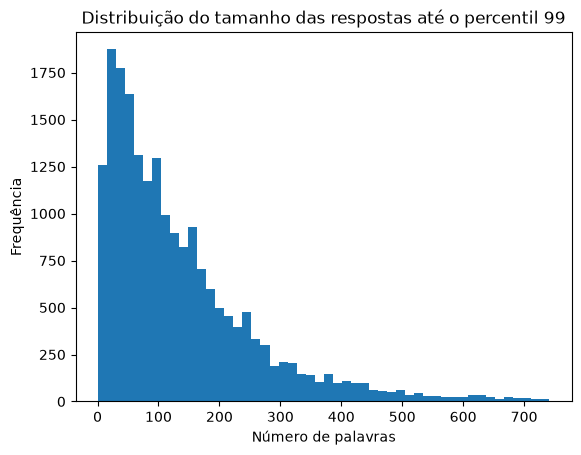

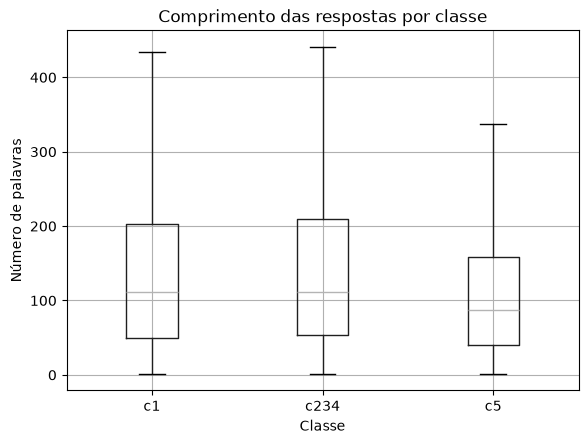

In [46]:
df["n_chars"] = df["resp_text"].str.len()
df["n_words"] = df["resp_text"].str.split().str.len()

df[["n_chars", "n_words"]].describe(
    percentiles=[0.5, 0.75, 0.90, 0.95, 0.99]
)

ax = df["n_words"].plot(
    kind="hist",
    bins=50
)

ax.set_title("Distribuição do tamanho das respostas")
ax.set_xlabel("Número de palavras")
ax.set_ylabel("Frequência")

plt.show()

limit = df["n_words"].quantile(0.99)

ax = df.loc[df["n_words"] <= limit, "n_words"].plot(
    kind="hist",
    bins=50
)

ax.set_title("Distribuição do tamanho das respostas até o percentil 99")
ax.set_xlabel("Número de palavras")
ax.set_ylabel("Frequência")

plt.show()

df.groupby("clarity")[["n_chars", "n_words"]].agg(
    ["mean", "median"]
)

df.boxplot(
    column="n_words",
    by="clarity",
    showfliers=False
)

plt.title("Comprimento das respostas por classe")
plt.suptitle("")
plt.xlabel("Classe")
plt.ylabel("Número de palavras")
plt.show()

In [47]:
print("Distribuição das classes:")
print(df["clarity"].value_counts().sort_index())

print("\nProporção das classes:")
print(
    df["clarity"]
      .value_counts(normalize=True)
      .sort_index()
      .mul(100)
      .round(2)
)

print("\nTextos vazios:")
print((df["resp_text"].str.strip() == "").sum())

print("\nEstatísticas de comprimento:")
display(
    df[["n_chars", "n_words"]].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

Distribuição das classes:
clarity
c1      6347
c234    6853
c5      6892
Name: count, dtype: int64

Proporção das classes:
clarity
c1      31.59
c234    34.11
c5      34.30
Name: proportion, dtype: float64

Textos vazios:
0

Estatísticas de comprimento:


,n_chars,n_words
count,20092.000000,20092.000000
mean,1000.381644,144.274288
std,1014.001503,149.866288
min,7.000000,1.000000
50%,709.000000,101.000000
75%,1311.000000,188.000000
90%,2122.000000,309.000000
95%,2877.450000,419.000000
99%,5040.360000,741.090000
max,12125.000000,1821.000000


## 6. Comprimento dos textos no tokenizador do BERTimbau

O comprimento em palavras não corresponde diretamente ao comprimento utilizado
por modelos Transformer. Nesta etapa, os textos são tokenizados com o mesmo
tokenizador que será utilizado pelo BERTimbau para avaliar a proporção do corpus
que cabe em diferentes limites de sequência.

Essa análise será utilizada para fundamentar a escolha de `max_length`.

Modelo: neuralmind/bert-base-portuguese-cased
Número máximo de posições suportado: 512

max_length = 128
Textos truncados: 12683 (63.12%)
Tokens removidos no corpus: 2,962,261

max_length = 256
Textos truncados: 7204 (35.86%)
Tokens removidos no corpus: 1,717,164

max_length = 512
Textos truncados: 2174 (10.82%)
Tokens removidos no corpus: 659,386


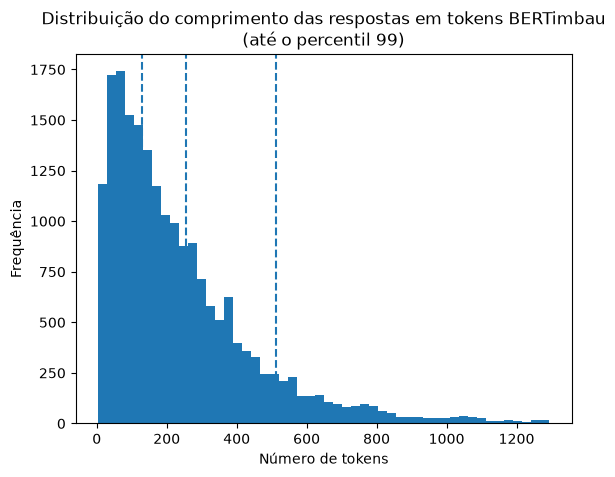

,count,mean,std,min,50%,75%,90%,95%,max
clarity,,,,,,,,,
c1,6347.0,267.800693,267.329051,4.0,199.0,354.0,556.0,762.7,4429.0
c234,6853.0,275.130600,274.353833,4.0,203.0,362.0,566.8,756.4,3140.0
c5,6892.0,218.638712,231.767837,4.0,153.0,280.0,464.0,615.0,3489.0


In [48]:
from transformers import AutoTokenizer

from transformers import AutoConfig

MODEL_NAME = "neuralmind/bert-base-portuguese-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config = AutoConfig.from_pretrained(MODEL_NAME)

print("Modelo:", MODEL_NAME)
print(
    "Número máximo de posições suportado:",
    config.max_position_embeddings
)

token_lengths = []

texts = df["resp_text"].tolist()

batch_size = 256

for start in range(0, len(texts), batch_size):
    batch = texts[start:start + batch_size]

    encoded = tokenizer(
        batch,
        add_special_tokens=True,
        truncation=False,
        padding=False,
        return_length=True,
        verbose=False,
    )

    token_lengths.extend(encoded["length"])

df["n_tokens_bertimbau"] = token_lengths

df[["resp_text", "n_words", "n_tokens_bertimbau"]].head()

len(token_lengths), len(df)

df["n_tokens_bertimbau"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

limits = [128, 256, 512]

coverage = pd.DataFrame({
    "max_length": limits,
    "textos_que_cabem": [
        (df["n_tokens_bertimbau"] <= limit).sum()
        for limit in limits
    ],
    "percentual_que_cabe": [
        (df["n_tokens_bertimbau"] <= limit).mean() * 100
        for limit in limits
    ],
    "percentual_truncado": [
        (df["n_tokens_bertimbau"] > limit).mean() * 100
        for limit in limits
    ],
})

coverage

for limit in [128, 256, 512]:
    excess = (df["n_tokens_bertimbau"] - limit).clip(lower=0)

    print(f"\nmax_length = {limit}")
    print(
        f"Textos truncados: "
        f"{(df['n_tokens_bertimbau'] > limit).sum()} "
        f"({(df['n_tokens_bertimbau'] > limit).mean() * 100:.2f}%)"
    )
    print(
        f"Tokens removidos no corpus: {excess.sum():,}"
    )

    limit_99 = df["n_tokens_bertimbau"].quantile(0.99)

ax = df.loc[
    df["n_tokens_bertimbau"] <= limit_99,
    "n_tokens_bertimbau"
].plot(
    kind="hist",
    bins=50
)

ax.set_title(
    "Distribuição do comprimento das respostas em tokens BERTimbau\n"
    "(até o percentil 99)"
)
ax.set_xlabel("Número de tokens")
ax.set_ylabel("Frequência")

for limit in [128, 256, 512]:
    plt.axvline(limit, linestyle="--")

plt.show()

df.groupby("clarity")["n_tokens_bertimbau"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95]
)

In [49]:
limits = [128, 256, 384, 512]

coverage = pd.DataFrame({
    "max_length": limits,
    "textos_que_cabem": [
        (df["n_tokens_bertimbau"] <= limit).sum()
        for limit in limits
    ],
    "percentual_que_cabe": [
        (df["n_tokens_bertimbau"] <= limit).mean() * 100
        for limit in limits
    ],
    "percentual_truncado": [
        (df["n_tokens_bertimbau"] > limit).mean() * 100
        for limit in limits
    ],
})

coverage.round(2)


,max_length,textos_que_cabem,percentual_que_cabe,percentual_truncado
0,128,7409,36.88,63.12
1,256,12888,64.14,35.86
2,384,16287,81.06,18.94
3,512,17918,89.18,10.82


In [50]:

rows = []

for clarity, group in df.groupby("clarity"):
    for limit in [128, 256, 384, 512]:
        n_total = len(group)
        n_truncated = (group["n_tokens_bertimbau"] > limit).sum()

        rows.append({
            "classe": clarity,
            "max_length": limit,
            "total": n_total,
            "truncados": n_truncated,
            "percentual_truncado": 100 * n_truncated / n_total
        })

truncation_by_class = pd.DataFrame(rows)

truncation_by_class

truncation_by_class.pivot(
    index="classe",
    columns="max_length",
    values="percentual_truncado"
).round(2)

max_length,128,256,384,512
classe,,,,
c1,65.51,39.01,20.73,12.26
c234,66.76,40.04,22.05,12.48
c5,57.31,28.79,14.19,7.85
